In [334]:
import pandas as pd
import numpy as np
from scipy import stats
import matplotlib.pyplot as plt
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.stattools import adfuller

print("All imports done")

All imports done


In [335]:

df = pd.read_csv(
    "gold_arimax_data.csv",
    parse_dates=["Date"],
    index_col="Date"
)


In [336]:
df.head()

,Gold Price,Interest Rate,Inflation Changes,Oil Price,DXY,GPRHT,SPX500
Date,,,,,,,
1975-01-01,176.25,7.50,0.39,11.16,95.61,83.86,76.98
1975-01-02,181.75,7.39,0.77,11.16,93.00,112.83,81.59
1975-01-03,177.75,7.73,0.38,11.16,94.82,81.50,83.36
1975-01-04,167.40,8.23,0.38,11.16,95.39,89.52,87.30
1975-01-05,167.75,8.06,0.57,11.16,94.63,91.75,91.15


In [337]:
df.columns = df.columns.str.replace(" ", "_")

In [338]:
df.info()

<class 'pandas.DataFrame'>
DatetimeIndex: 613 entries, 1975-01-01 to NaT
Data columns (total 7 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Gold_Price         612 non-null    float64
 1   Interest_Rate      612 non-null    float64
 2   Inflation_Changes  612 non-null    float64
 3   Oil_Price          612 non-null    float64
 4   DXY                612 non-null    float64
 5   GPRHT              612 non-null    float64
 6   SPX500             612 non-null    float64
dtypes: float64(7)
memory usage: 38.3 KB


<Axes: xlabel='Date'>

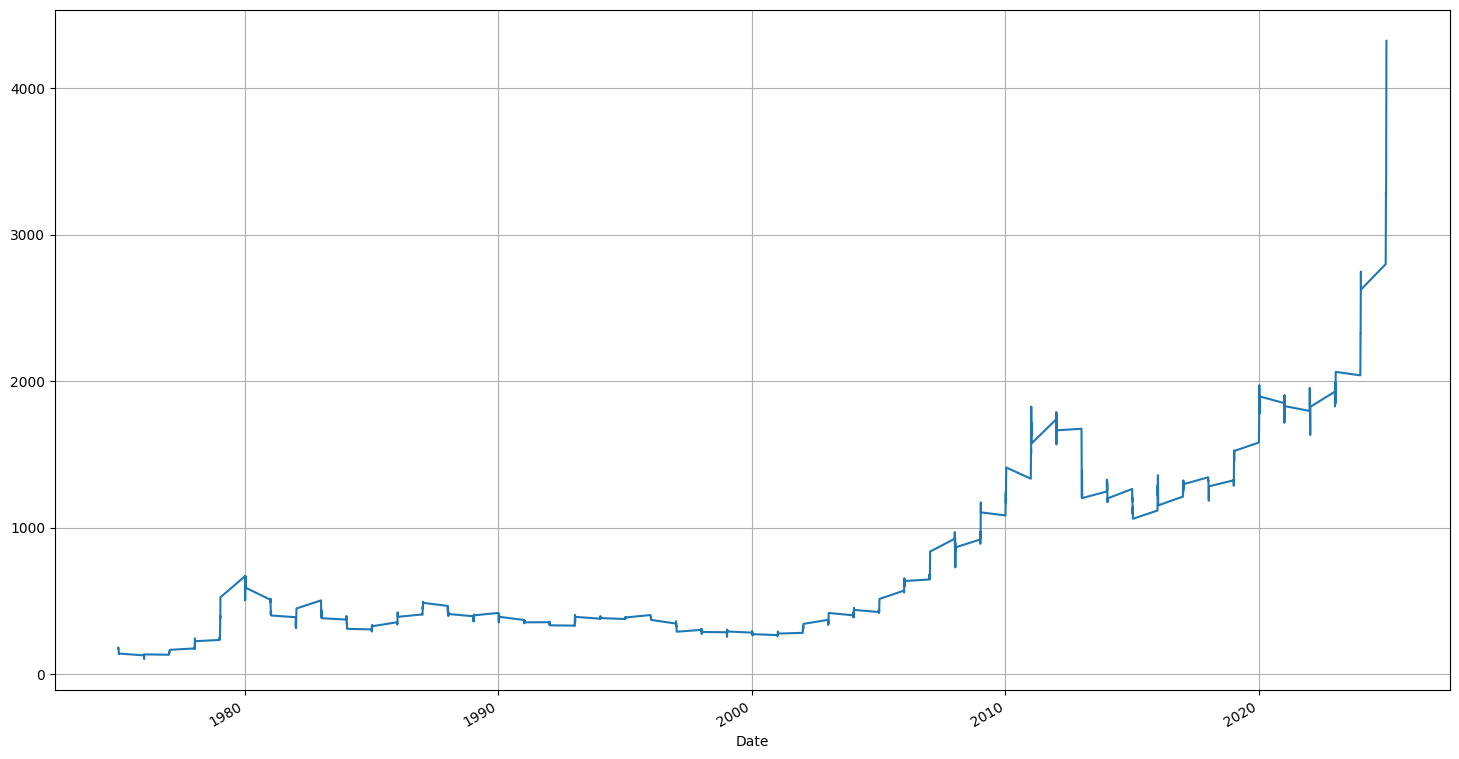

In [339]:
df["Gold_Price"].plot(figsize=(18,10), grid=True)

In [340]:

# Correct order: transformed data first, lambda second
transformed, lambda_val = stats.boxcox(df["Gold_Price"].dropna())
print(f"Gold_Price_lambda: {lambda_val:.4f}")

Gold_Price_lambda: -0.2087


<Axes: title={'center': 'Gold Log'}, xlabel='Date'>

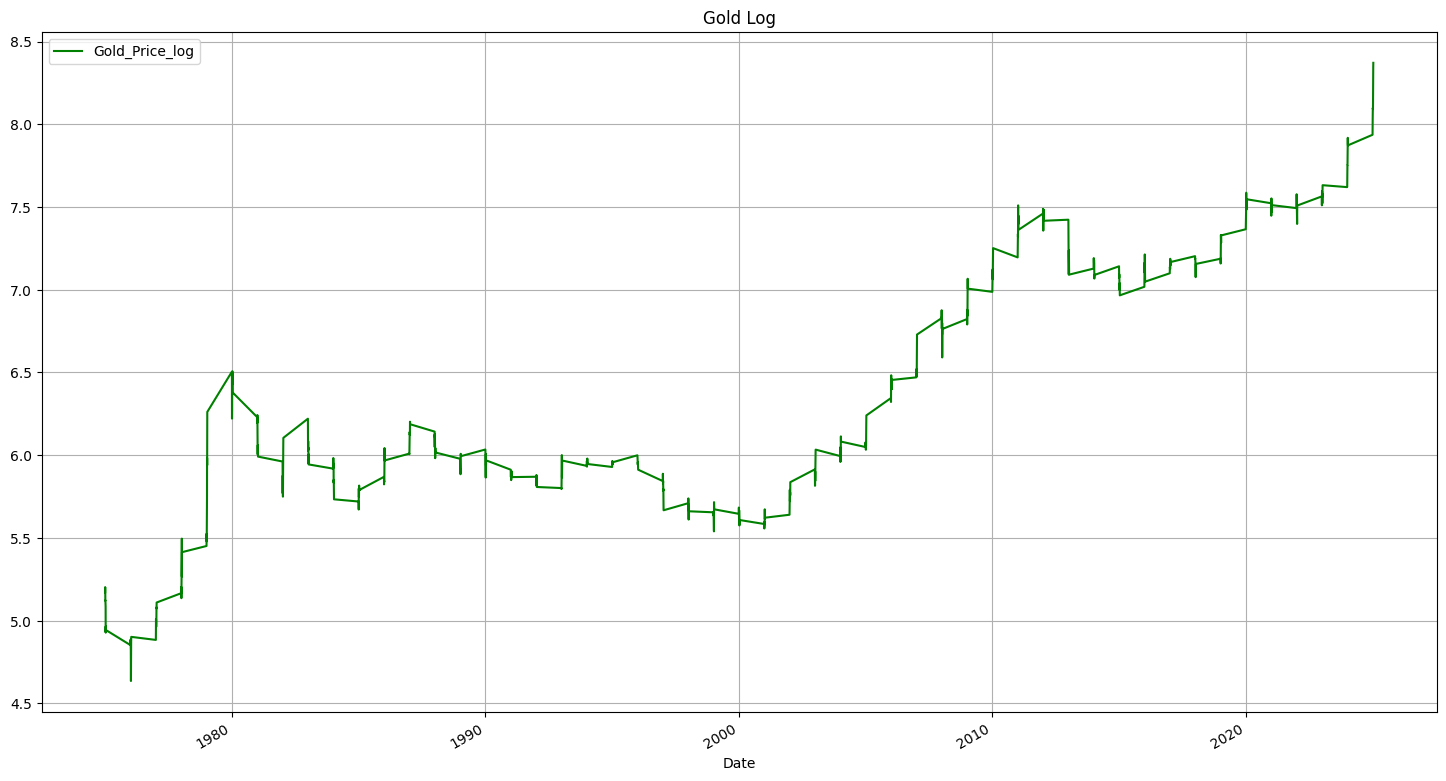

In [341]:

# Log transform
df["Gold_Price_log"] = np.log(df["Gold_Price"])


df[["Gold_Price_log"]].plot(figsize=(18,10), title="Gold Log", grid=True, color="green")

<Axes: xlabel='Date'>

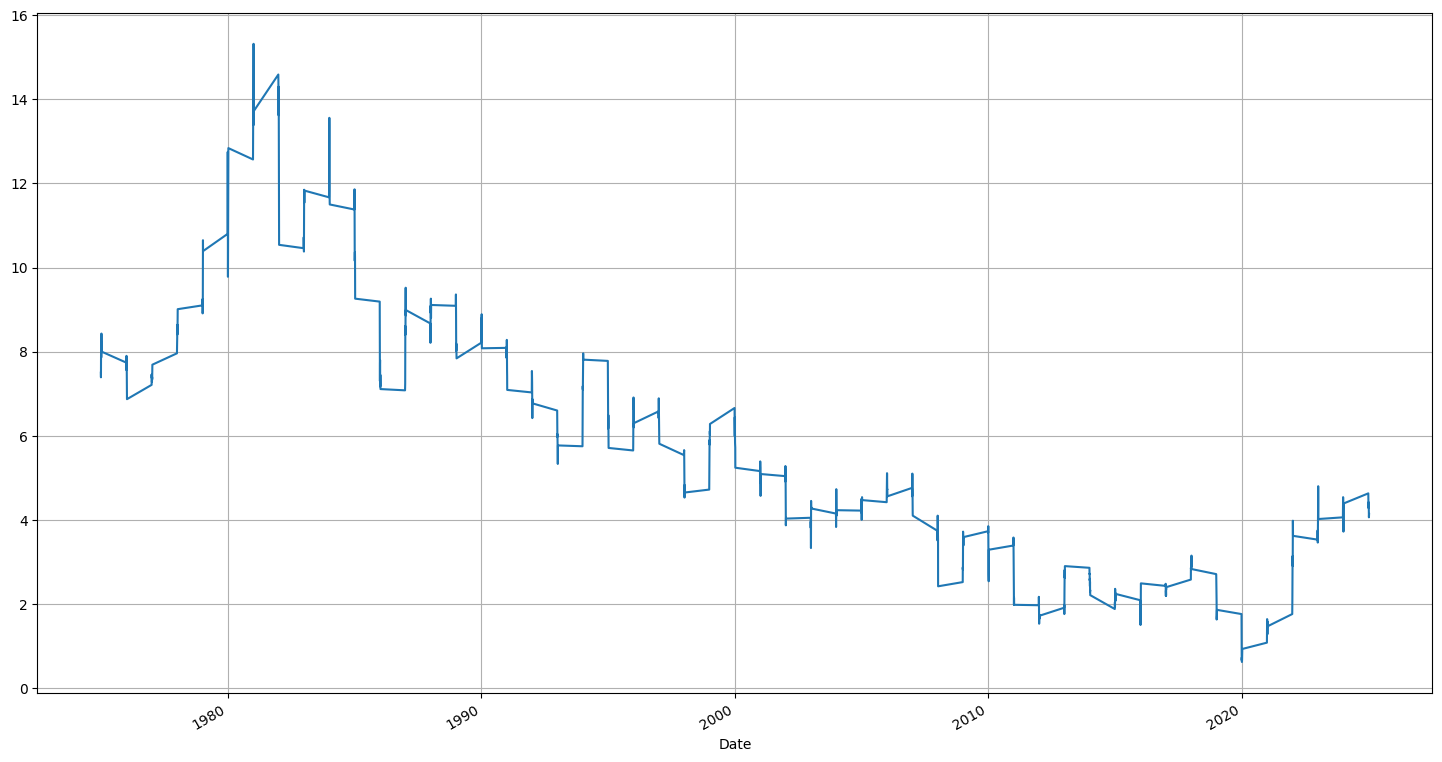

In [342]:
df["Interest_Rate"].plot(figsize=(18,10), grid=True)

In [343]:
transformed, lambda_val = stats.boxcox(df["Interest_Rate"].dropna())
print(f"Interest_Rate_lambda: {lambda_val:.4f}")

Interest_Rate_lambda: 0.3891


<Axes: xlabel='Date'>

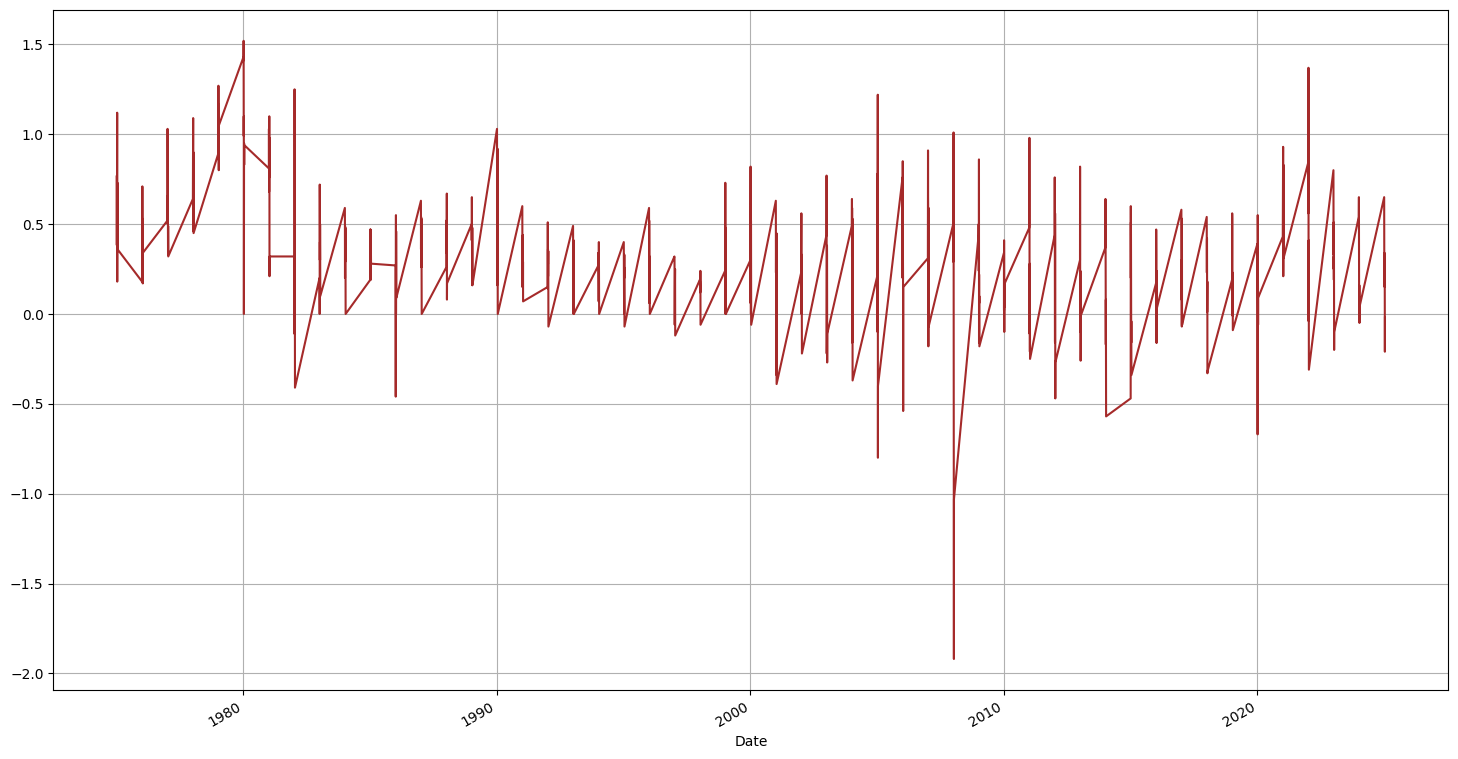

In [344]:
df["Inflation_Changes"].plot(figsize=(18,10), grid=True, color="brown")

<Axes: xlabel='Date'>

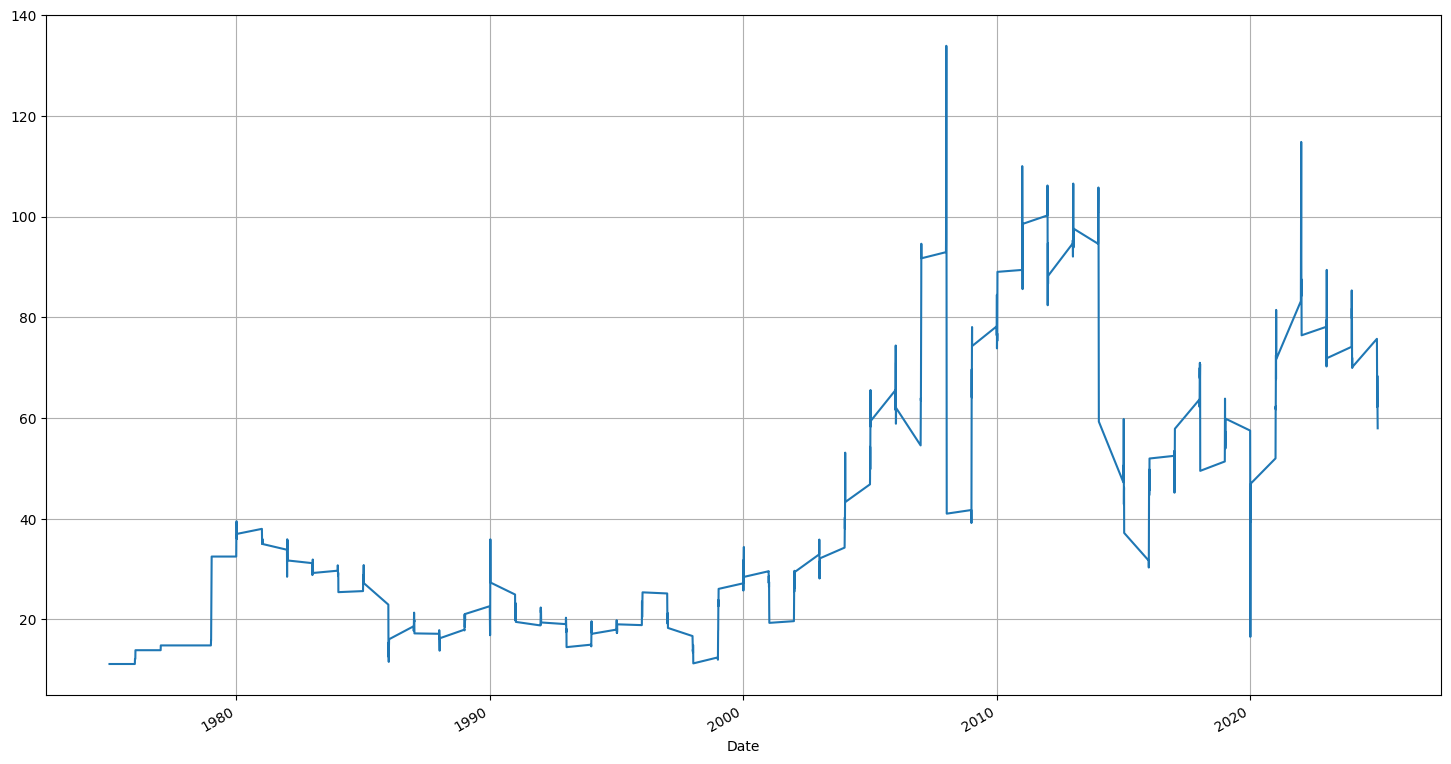

In [345]:
df["Oil_Price"].plot(figsize=(18,10), grid=True)

In [346]:
transformed, lambda_val = stats.boxcox(df["Oil_Price"].dropna())
print(f"Oil_Price_lambda: {lambda_val:.4f}")

Oil_Price_lambda: -0.1172


<Axes: title={'center': 'Oil_Price_Log'}, xlabel='Date'>

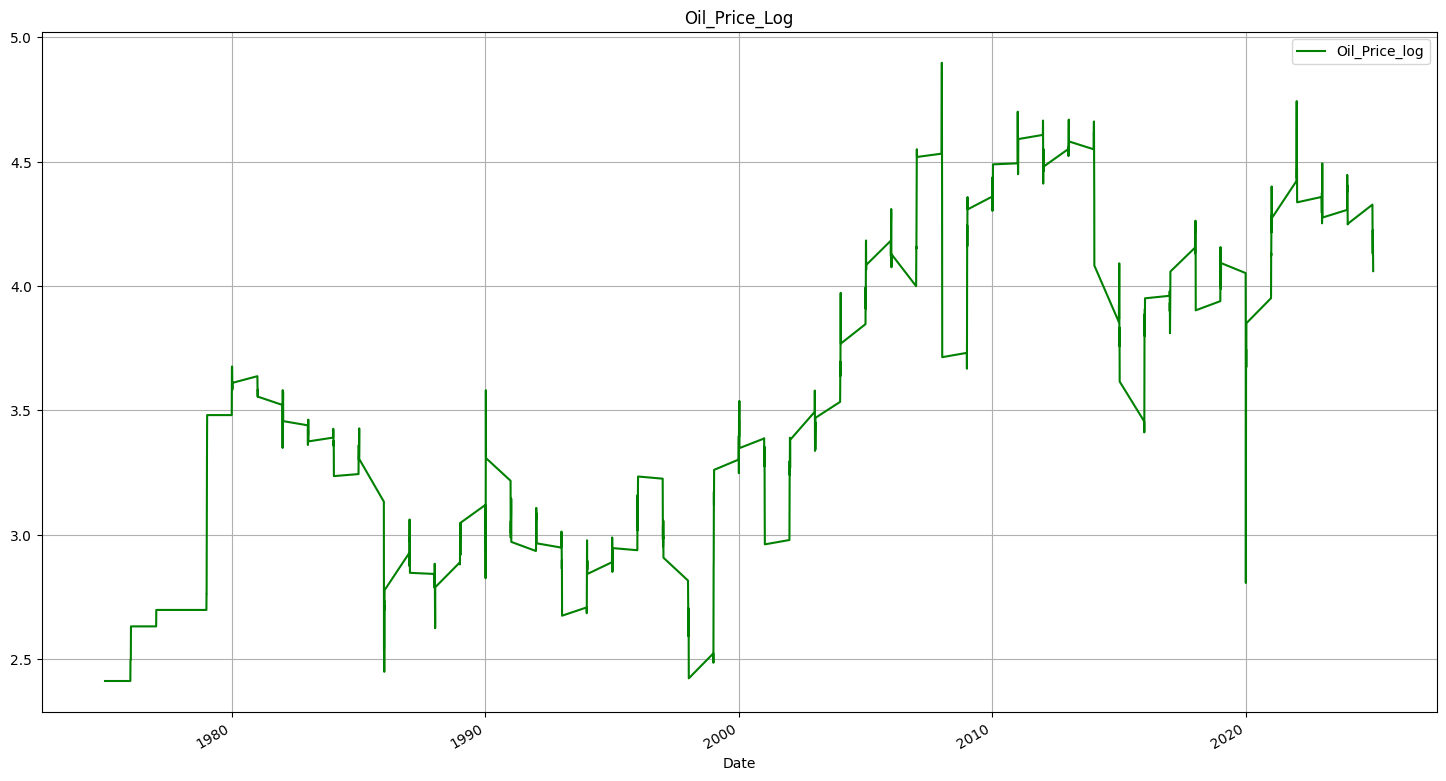

In [347]:
# Log transform
df["Oil_Price_log"] = np.log(df["Oil_Price"])


df[["Oil_Price_log"]].plot(figsize=(18,10), title="Oil_Price_Log", grid=True, color="green")

<Axes: xlabel='Date'>

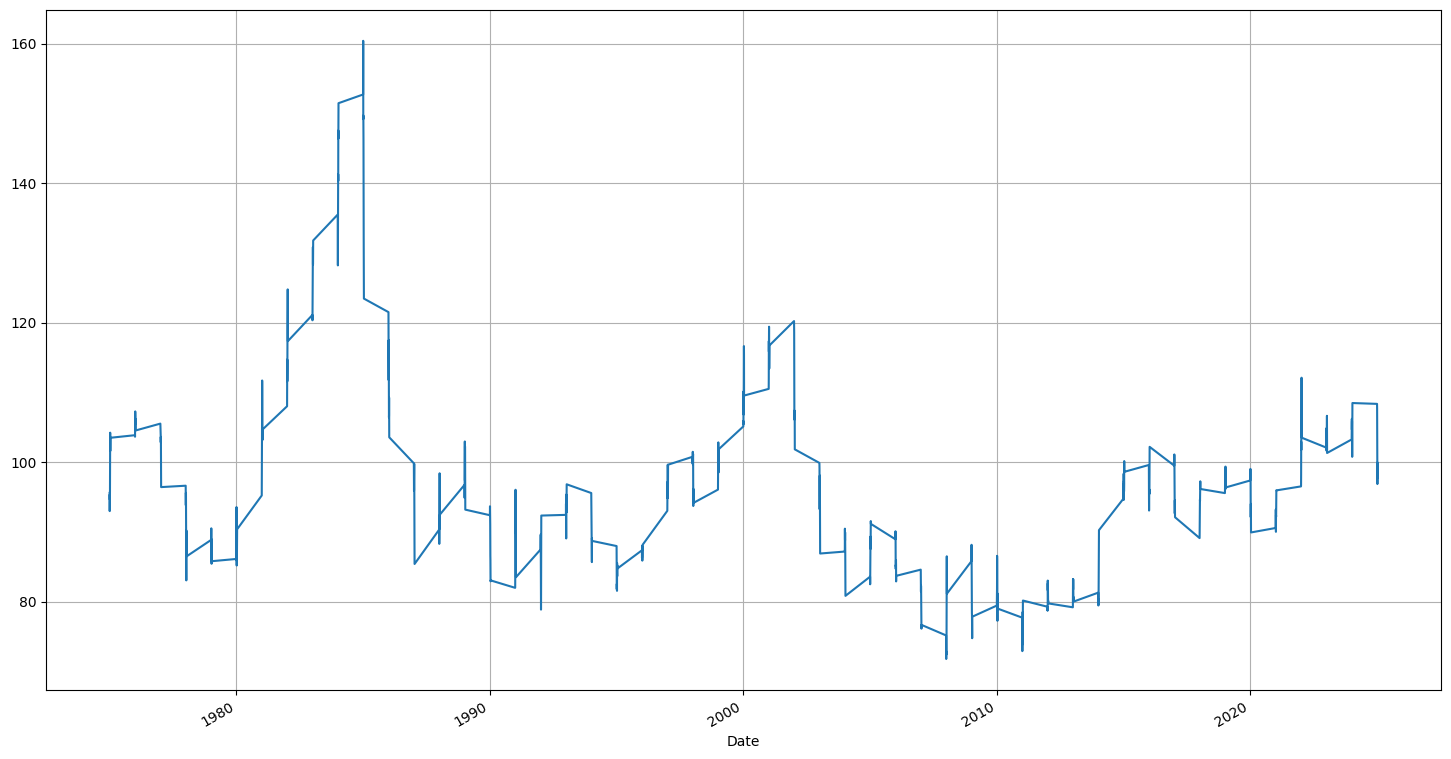

In [348]:
df["DXY"].plot(figsize=(18,10), grid=True)

In [349]:


# Correct order: transformed data first, lambda second
transformed, lambda_val = stats.boxcox(df["DXY"].dropna())
print(f"DXY lambda: {lambda_val:.4f}")

DXY lambda: -1.6893


<Axes: xlabel='Date'>

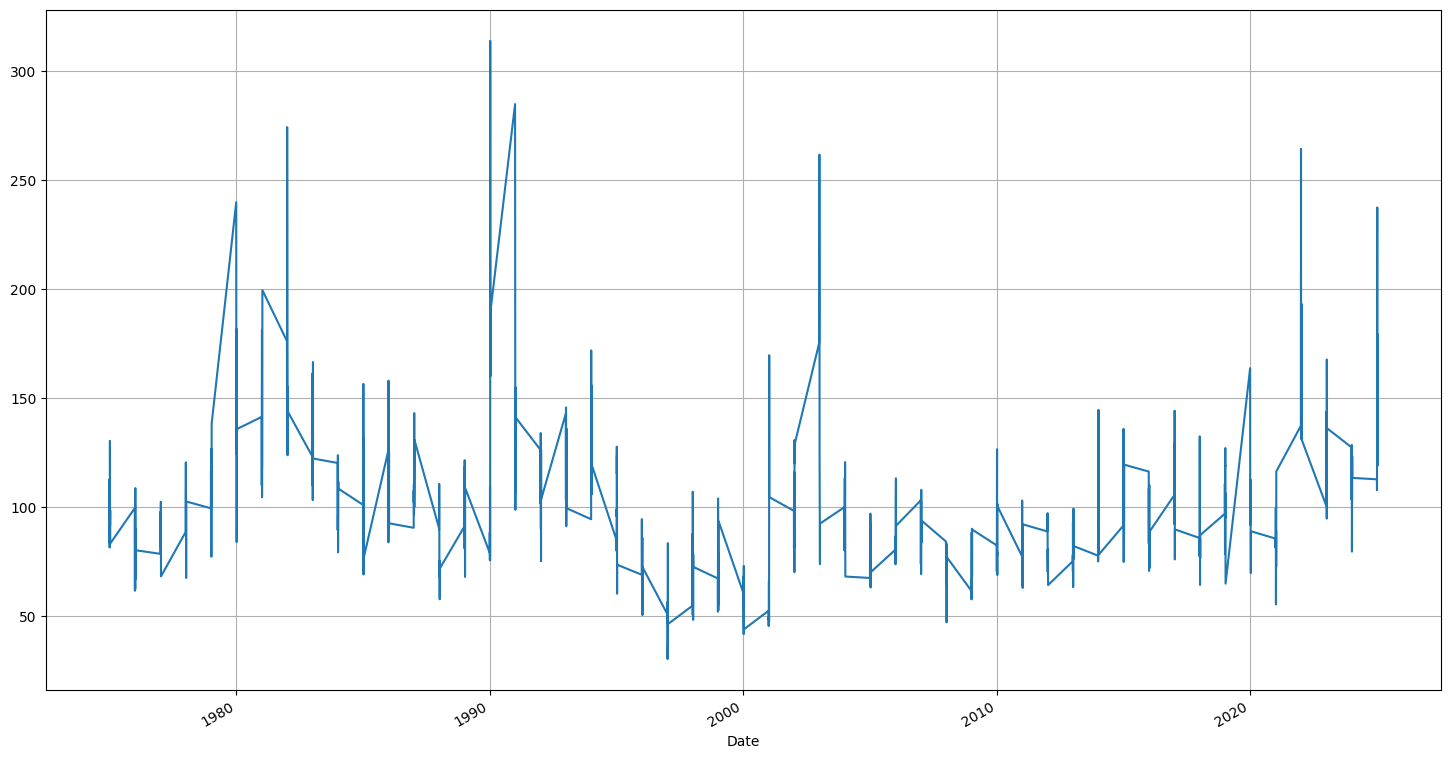

In [350]:
df["GPRHT"].plot(figsize=(18,10), grid=True)

In [351]:
# Correct order: transformed data first, lambda second
transformed, lambda_val = stats.boxcox(df["GPRHT"].dropna())
print(f"GPRHT lambda: {lambda_val:.4f}")

GPRHT lambda: -0.1111


<Axes: title={'center': 'GPRHT Log'}, xlabel='Date'>

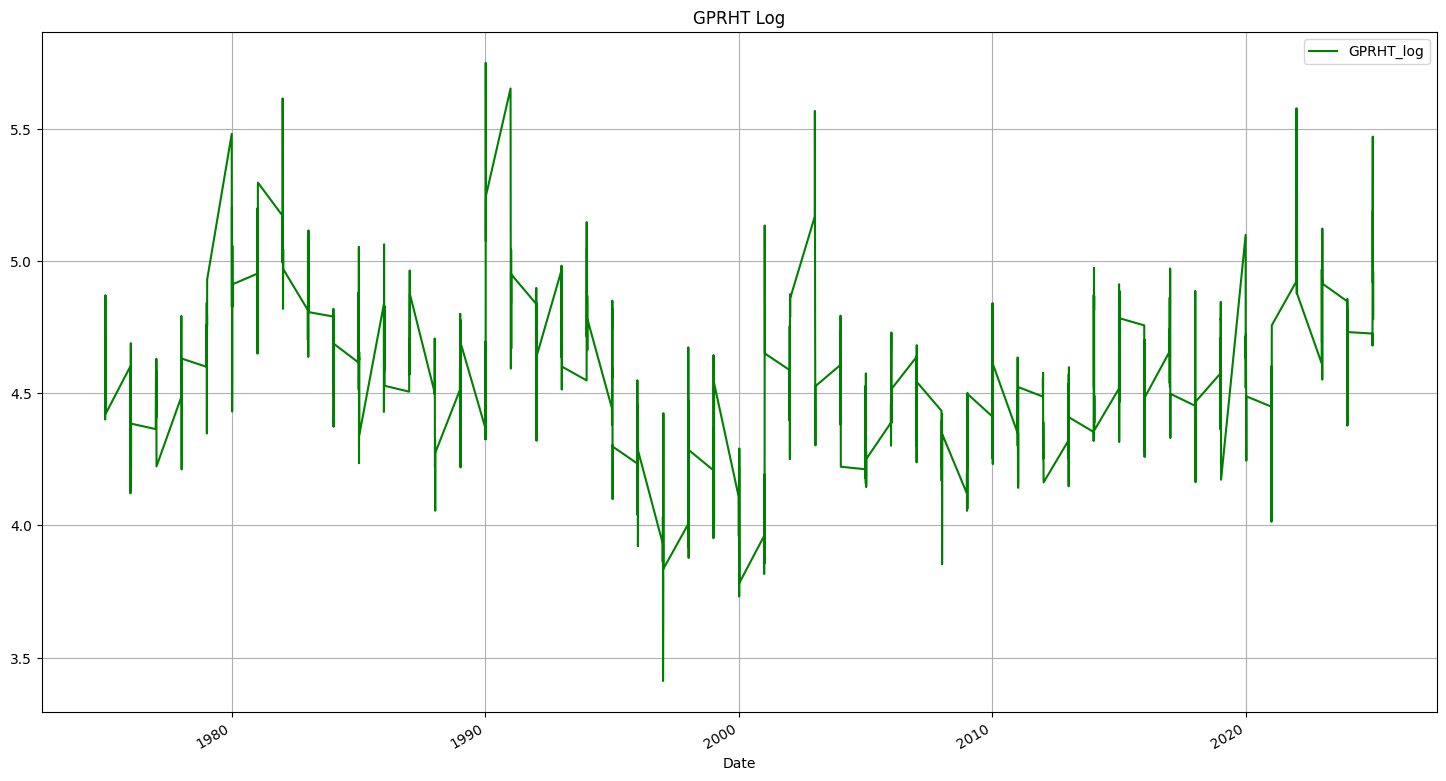

In [352]:
df["GPRHT_log"] = np.log(df["GPRHT"])


df[["GPRHT_log"]].plot(figsize=(18,10), title="GPRHT Log", grid=True, color="green")

<Axes: xlabel='Date'>

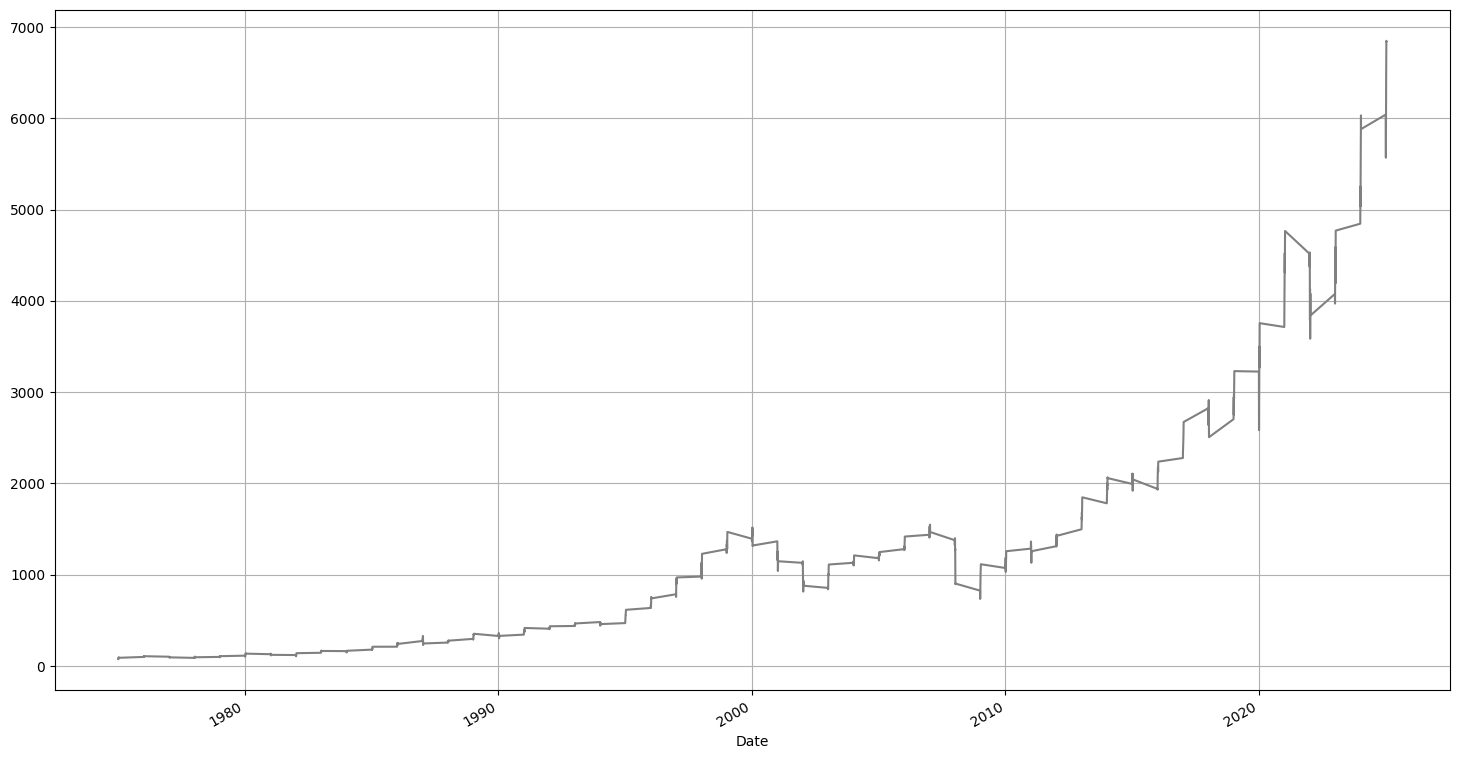

In [353]:
df["SPX500"].plot(figsize=(18,10), grid=True, color="grey")

In [354]:
transformed, lambda_val = stats.boxcox(df["SPX500"].dropna())
print(f"SPX500_lambda: {lambda_val:.4f}")

SPX500_lambda: 0.0972


<Axes: title={'center': 'SPX500 Log'}, xlabel='Date'>

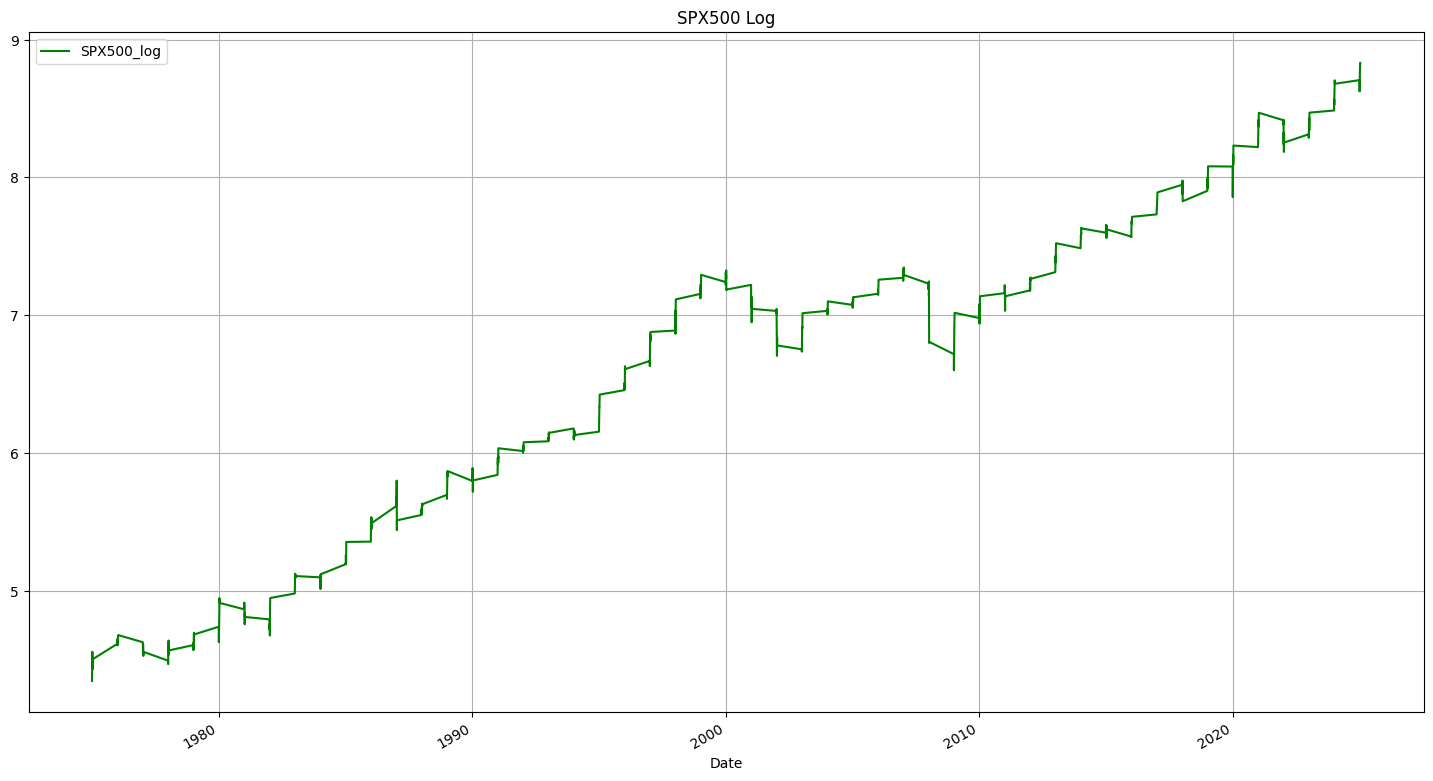

In [355]:
df["SPX500_log"] = np.log(df["SPX500"])


df[["SPX500_log"]].plot(figsize=(18,10), title="SPX500 Log", grid=True, color="green")

In [356]:
#Been Log
#Gold/ Oil/ GPRHT/ SPX500

In [357]:
df_train = df[df.index.year <= 2024]
df_test  = df[df.index.year == 2025]

In [358]:
# Define exactly which version to use for each variable
cols_to_test = [
    "Gold_Price_log",      # log version
    "Oil_Price_log",       # log version
    "GPRHT_log",     # log version
    "SPX500_log",    # log version
    "DXY",  
    "Inflation_Changes",# original
    "Interest_Rate", # original
]

for col in cols_to_test:
    result = adfuller(df_train[col].dropna())
    pval = result[1]
    status = "stationary" if pval <= 0.05 else "NON-STATIONARY"
    print(f"{col}: p-value = {pval:.4f} → {status}")

Gold_Price_log: p-value = 0.7027 → NON-STATIONARY
Oil_Price_log: p-value = 0.2088 → NON-STATIONARY
GPRHT_log: p-value = 0.0000 → stationary
SPX500_log: p-value = 0.8863 → NON-STATIONARY
DXY: p-value = 0.2053 → NON-STATIONARY
Inflation_Changes: p-value = 0.0470 → stationary
Interest_Rate: p-value = 0.6631 → NON-STATIONARY


Gold_Price_log_d1: p-value = 0.0000 → stationary ✓
Oil_Price_log_d1: p-value = 0.0000 → stationary ✓
SPX500_log_d1: p-value = 0.0000 → stationary ✓
DXY_d1: p-value = 0.0000 → stationary ✓
Interest_Rate_d1: p-value = 0.0000 → stationary ✓
GPRHT_log: p-value = 0.0000 → stationary ✓
Inflation_Changes: p-value = 0.0470 → stationary ✓


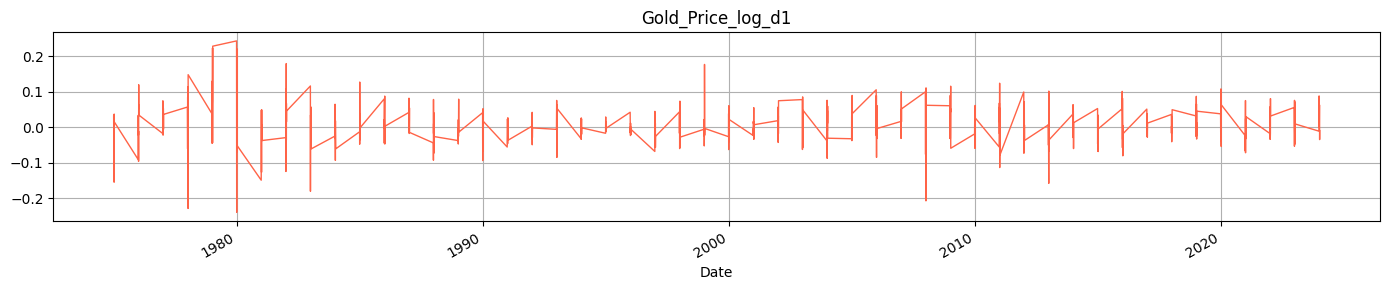

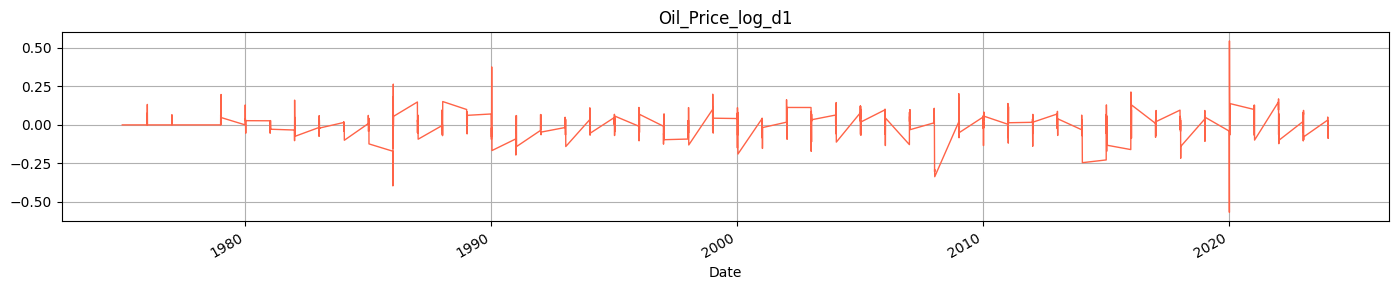

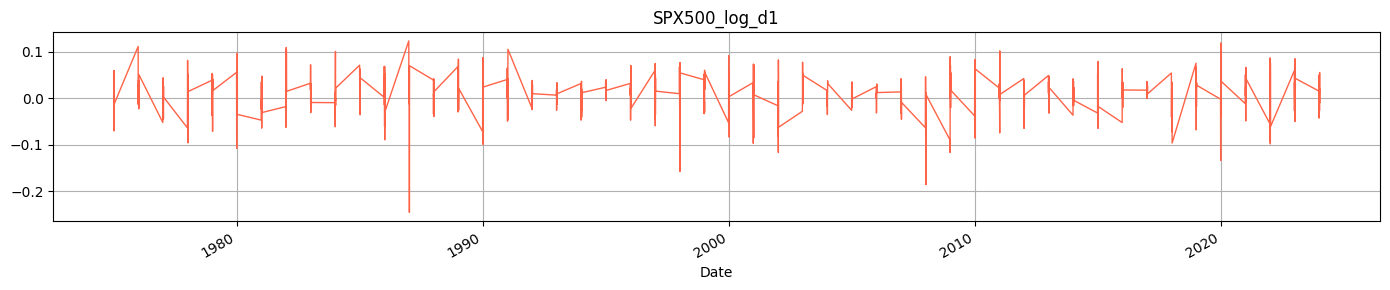

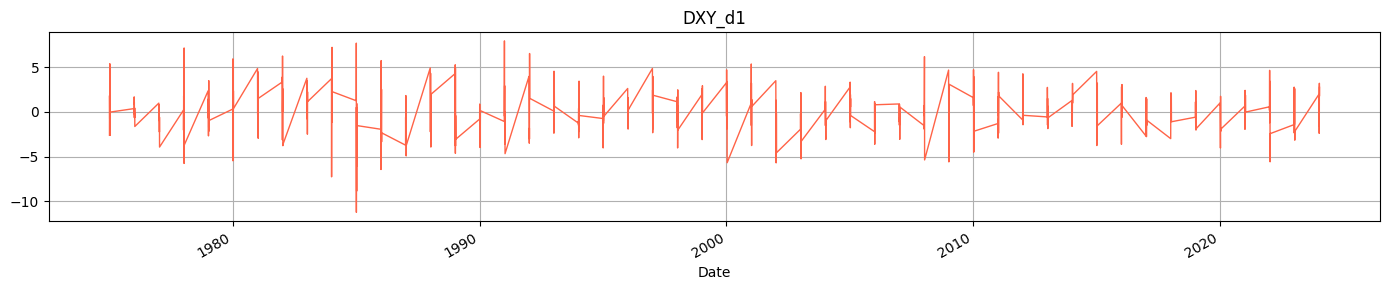

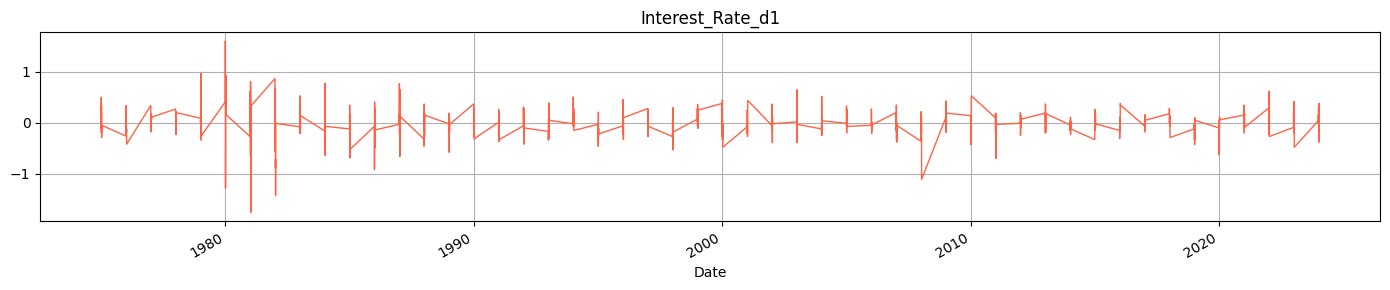

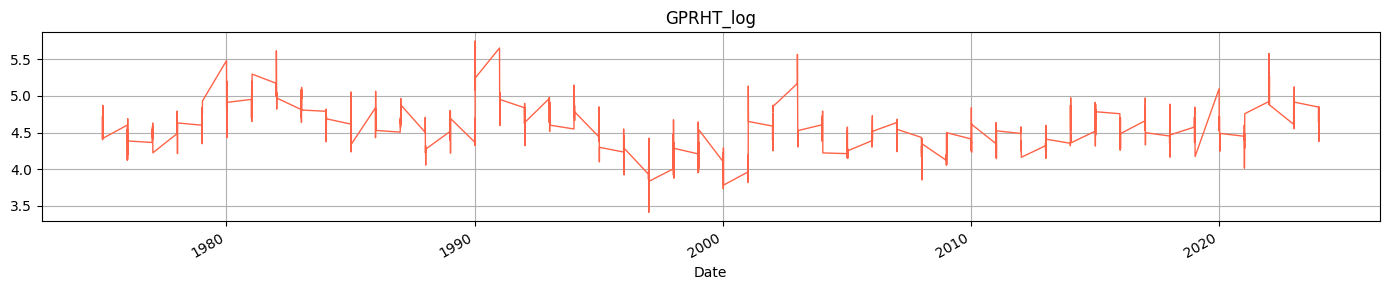

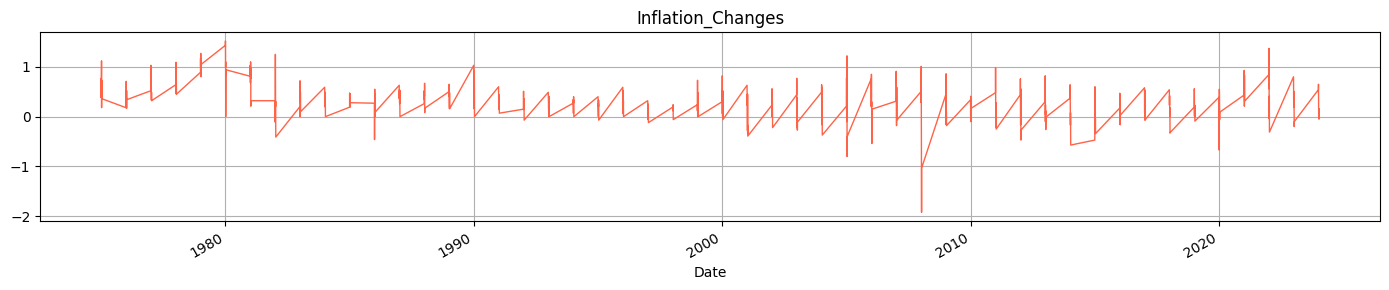

In [359]:
# Apply first difference to non-stationary variables
diff_cols = ["Gold_Price_log", "Oil_Price_log", "SPX500_log", 
             "DXY", "Interest_Rate"]

for col in diff_cols:
    df_train[col + "_d1"] = df_train[col].diff()

# Re-run ADF on differenced versions
cols_retest = [
    "Gold_Price_log_d1",
    "Oil_Price_log_d1", 
    "SPX500_log_d1",
    "DXY_d1",
    "Interest_Rate_d1",
    "GPRHT_log",        # already stationary
    "Inflation_Changes" # already stationary
]

for col in cols_retest:
    result = adfuller(df_train[col].dropna())
    pval = result[1]
    status = "stationary ✓" if pval <= 0.05 else "STILL NON-STATIONARY"
    print(f"{col}: p-value = {pval:.4f} → {status}")

    # ── Plot stationary versions only ──────────────────────────────

for col in cols_retest:
    df_train[col].plot(figsize=(14, 3), color="tomato", 
                       linewidth=1, grid=True, title=col)
    plt.tight_layout()
    plt.show()

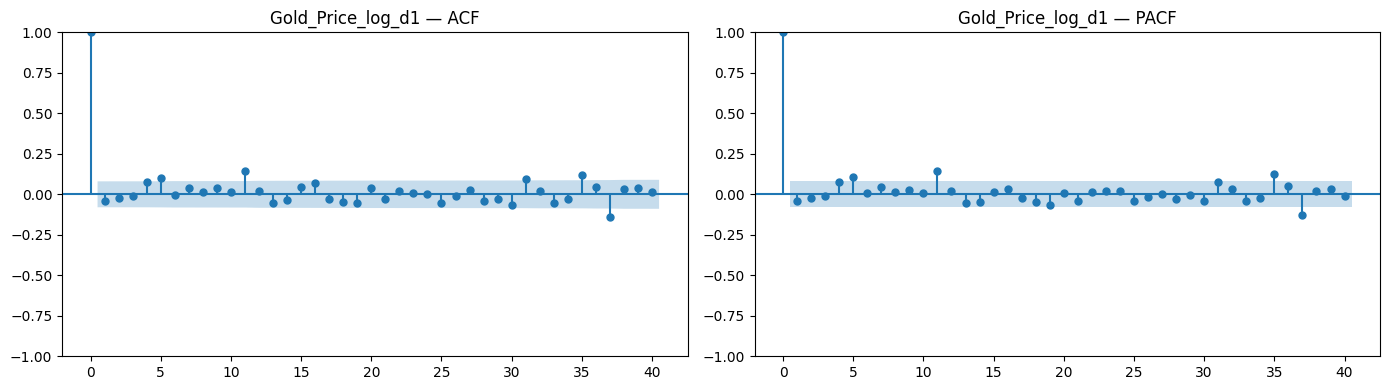

In [360]:
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf


fig, axes = plt.subplots(1, 2, figsize=(14, 4))

plot_acf(df_train["Gold_Price_log_d1"].dropna(), lags=40, ax=axes[0])
plot_pacf(df_train["Gold_Price_log_d1"].dropna(), lags=40, ax=axes[1])

axes[0].set_title("Gold_Price_log_d1 — ACF")
axes[1].set_title("Gold_Price_log_d1 — PACF")

plt.tight_layout()
plt.show()


In [361]:
!pip install pmdarima



[notice] A new release of pip is available: 26.1.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [362]:
from pmdarima import auto_arima

auto_model = auto_arima(
    df_train["Gold_Price_log_d1"].dropna(),
    d=0,              # already differenced
    start_p=0, max_p=3,
    start_q=0, max_q=3,
    information_criterion="aic",
    stepwise=True,
    suppress_warnings=True
)

print(auto_model.summary())

                               SARIMAX Results                                
Dep. Variable:                      y   No. Observations:                  599
Model:                        SARIMAX   Log Likelihood                 911.224
Date:                Sat, 06 Jun 2026   AIC                          -1818.447
Time:                        23:29:02   BIC                          -1809.657
Sample:                             0   HQIC                         -1815.025
                                - 599                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
intercept      0.0045      0.002      2.085      0.037       0.000       0.009
sigma2         0.0028   9.68e-05     28.853      0.000       0.003       0.003
Ljung-Box (L1) (Q):                   1.04   Jarque-

In [363]:
# Apply log to test data
df_test["Gold_Price_log"] = np.log(df_test["Gold_Price"])
df_test["Oil_Price_log"]  = np.log(df_test["Oil_Price"])
df_test["SPX500_log"]     = np.log(df_test["SPX500"])

# Apply differencing to test data
# Must combine with last row of train to get correct first difference
full_data = pd.concat([df_train, df_test])

for col in ["Gold_Price_log", "Oil_Price_log", "SPX500_log", "DXY", "Interest_Rate"]:
    full_data[col + "_d1"] = full_data[col].diff()

# Extract test portion back
df_test = full_data[full_data.index.year == 2025].copy()

In [364]:
from statsmodels.tsa.statespace.sarimax import SARIMAX

# Define X variables (stationary versions)
exog_cols = [
    "Oil_Price_log_d1",
    "SPX500_log_d1",
    "DXY_d1",
    "Interest_Rate_d1",
    "GPRHT_log",
    "Inflation_Changes"
]

# Clean training data
train_clean = df_train[["Gold_Price_log"] + exog_cols].dropna()

# Build and fit model
model = SARIMAX(
    train_clean["Gold_Price_log"],
    exog=train_clean[exog_cols],
    order=(0, 1, 0),
    trend='c'
)

result = model.fit(disp=False)
print(result.summary())

                               SARIMAX Results                                
Dep. Variable:         Gold_Price_log   No. Observations:                  599
Model:               SARIMAX(0, 1, 0)   Log Likelihood                 936.383
Date:                Sat, 06 Jun 2026   AIC                          -1856.766
Time:                        23:29:03   BIC                          -1821.617
Sample:                             0   HQIC                         -1843.081
                                - 599                                         
Covariance Type:                  opg                                         
                        coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------------------------------------
intercept             0.0045      0.002      2.138      0.033       0.000       0.009
Oil_Price_log_d1      0.0117      0.024      0.495      0.620      -0.035       0.058
SPX500_log_d1        -0.

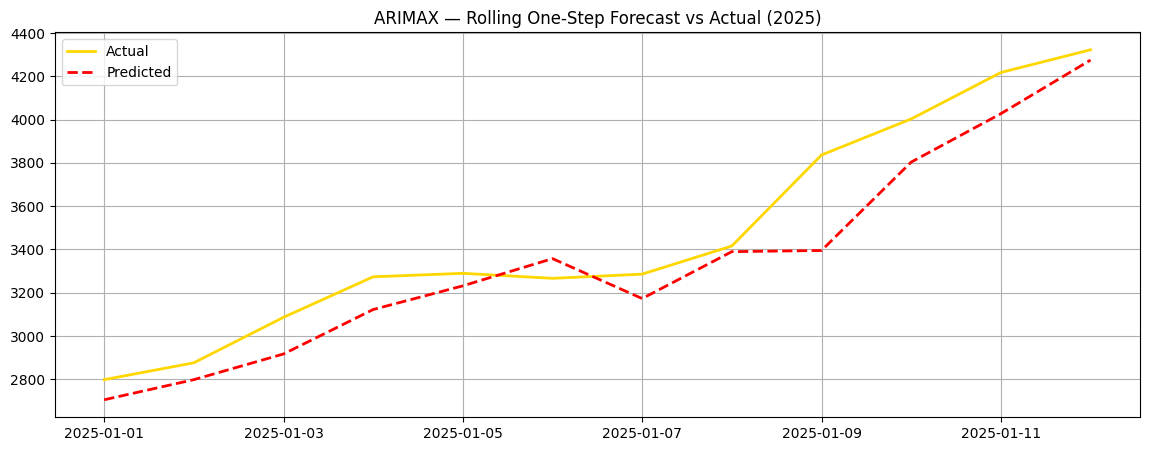

MAE  : 138.12
RMSE : 174.20
MAPE : 3.91%


In [371]:
import warnings
warnings.filterwarnings("ignore")

from statsmodels.tsa.statespace.sarimax import SARIMAX

predictions = []

for i in range(len(test_clean)):
    endog_temp = pd.concat([
        train_clean["Gold_Price_log"],
        df_test["Gold_Price_log"].iloc[:i]
    ])
    exog_temp = pd.concat([
        train_clean[exog_cols],
        test_clean.iloc[:i]
    ])
    
    temp_model = SARIMAX(endog_temp, exog=exog_temp, order=(0,1,0), trend='c')
    temp_result = temp_model.filter(result.params)
    
    pred = temp_result.forecast(steps=1, exog=test_clean.iloc[[i]])
    predictions.append(pred.iloc[0])

pred_log_rolling   = pd.Series(predictions, index=test_clean.index)
pred_price_rolling = np.exp(pred_log_rolling)
actual_price       = np.exp(df_test["Gold_Price_log"].dropna())

plt.figure(figsize=(14,5))
plt.plot(actual_price.index, actual_price, label="Actual", color="gold", linewidth=2)
plt.plot(pred_price_rolling.index, pred_price_rolling, label="Predicted", color="red", linestyle="--", linewidth=2)
plt.title("ARIMAX — Rolling One-Step Forecast vs Actual (2025)")
plt.legend()
plt.grid(True)
plt.show()

mae  = mean_absolute_error(actual_price, pred_price_rolling)
rmse = np.sqrt(mean_squared_error(actual_price, pred_price_rolling))
mape = np.mean(np.abs((actual_price - pred_price_rolling) / actual_price)) * 100

print(f"MAE  : {mae:.2f}")
print(f"RMSE : {rmse:.2f}")
print(f"MAPE : {mape:.2f}%")



In [366]:
import warnings
warnings.filterwarnings("ignore")

best_aic   = np.inf
best_order = None
results_table = []

for p in range(0, 4):
    for q in range(0, 4):
        try:
            m = SARIMAX(
                train_clean["Gold_Price_log"],
                exog=train_clean[exog_cols],
                order=(p, 1, q),
                trend='c'
            ).fit(disp=False)
            
            results_table.append({
                "order"  : f"({p},1,{q})",
                "AIC"    : round(m.aic, 2),
                "BIC"    : round(m.bic, 2)
            })
            
            if m.aic < best_aic:
                best_aic   = m.aic
                best_order = (p, 1, q)
                
        except:
            pass

# Print all results sorted by AIC
results_df = pd.DataFrame(results_table).sort_values("AIC")
print(results_df.to_string(index=False))
print(f"\nBest order: ARIMA{best_order}")
print(f"Best AIC  : {best_aic:.2f}")

  order      AIC      BIC
(0,1,0) -1856.77 -1821.62
(0,1,1) -1854.81 -1815.27
(1,1,0) -1854.81 -1815.27
(0,1,2) -1852.84 -1808.91
(2,1,0) -1852.84 -1808.91
(1,1,1) -1852.81 -1808.87
(3,1,0) -1851.49 -1803.16
(0,1,3) -1851.40 -1803.07
(2,1,1) -1850.84 -1802.51
(1,1,2) -1850.84 -1802.51
(3,1,1) -1849.74 -1797.02
(1,1,3) -1849.16 -1796.43
(2,1,2) -1848.84 -1796.12
(3,1,2) -1847.58 -1790.46
(2,1,3) -1847.22 -1790.10
(3,1,3) -1846.53 -1785.02

Best order: ARIMA(0, 1, 0)
Best AIC  : -1856.77


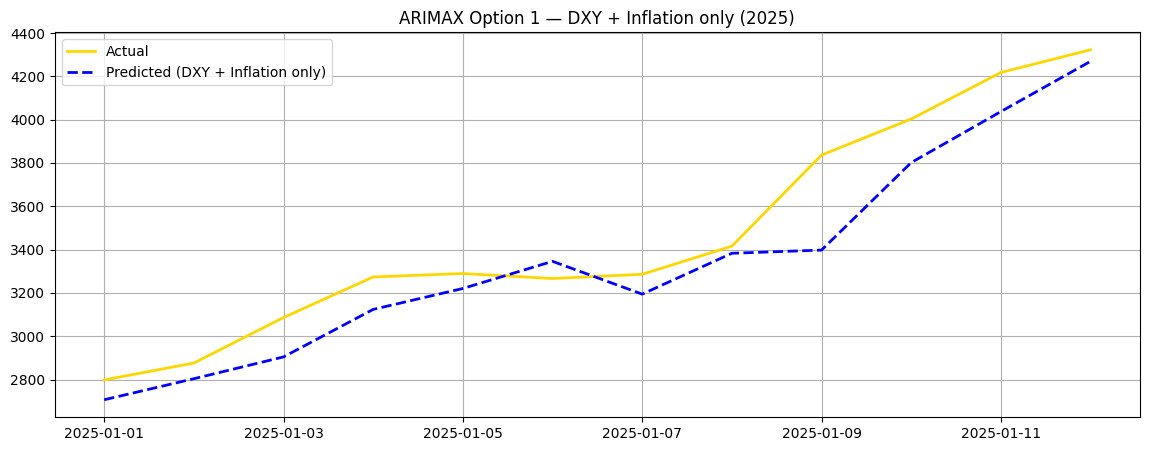

── Option 1 (DXY + Inflation) ──
MAE  : 136.79
RMSE : 172.66
MAPE : 3.87%



In [367]:
import warnings
warnings.filterwarnings("ignore")

# Option 1 — only significant variables
exog_cols_v2 = ["DXY_d1", "Inflation_Changes"]

# Prepare clean data with only 2 variables
train_clean2 = df_train[["Gold_Price_log"] + exog_cols_v2].dropna()
test_clean2  = df_test[exog_cols_v2].dropna()

# Fit new model
model2 = SARIMAX(
    train_clean2["Gold_Price_log"],
    exog=train_clean2[exog_cols_v2],
    order=(0, 1, 0),
    trend='c'
).fit(disp=False)

# Rolling one-step forecast
predictions2 = []

for i in range(len(test_clean2)):
    endog_temp = pd.concat([
        train_clean2["Gold_Price_log"],
        df_test["Gold_Price_log"].iloc[:i]
    ])
    exog_temp = pd.concat([
        train_clean2[exog_cols_v2],
        test_clean2.iloc[:i]
    ])
    
    temp_model  = SARIMAX(endog_temp, exog=exog_temp, order=(0,1,0), trend='c')
    temp_result = temp_model.filter(model2.params)
    pred        = temp_result.forecast(steps=1, exog=test_clean2.iloc[[i]])
    predictions2.append(pred.iloc[0])

pred_log_v2   = pd.Series(predictions2, index=test_clean2.index)
pred_price_v2 = np.exp(pred_log_v2)
actual_price  = np.exp(df_test["Gold_Price_log"].dropna())

# Plot
plt.figure(figsize=(14, 5))
plt.plot(actual_price.index, actual_price, label="Actual", color="gold", linewidth=2)
plt.plot(pred_price_v2.index, pred_price_v2, label="Predicted (DXY + Inflation only)", 
         color="Blue", linestyle="--", linewidth=2)
plt.title("ARIMAX Option 1 — DXY + Inflation only (2025)")
plt.legend()
plt.grid(True)
plt.show()

# Metrics
mae2  = mean_absolute_error(actual_price, pred_price_v2)
rmse2 = np.sqrt(mean_squared_error(actual_price, pred_price_v2))
mape2 = np.mean(np.abs((actual_price - pred_price_v2) / actual_price)) * 100

print("── Option 1 (DXY + Inflation) ──")
print(f"MAE  : {mae2:.2f}")
print(f"RMSE : {rmse2:.2f}")
print(f"MAPE : {mape2:.2f}%")
print()



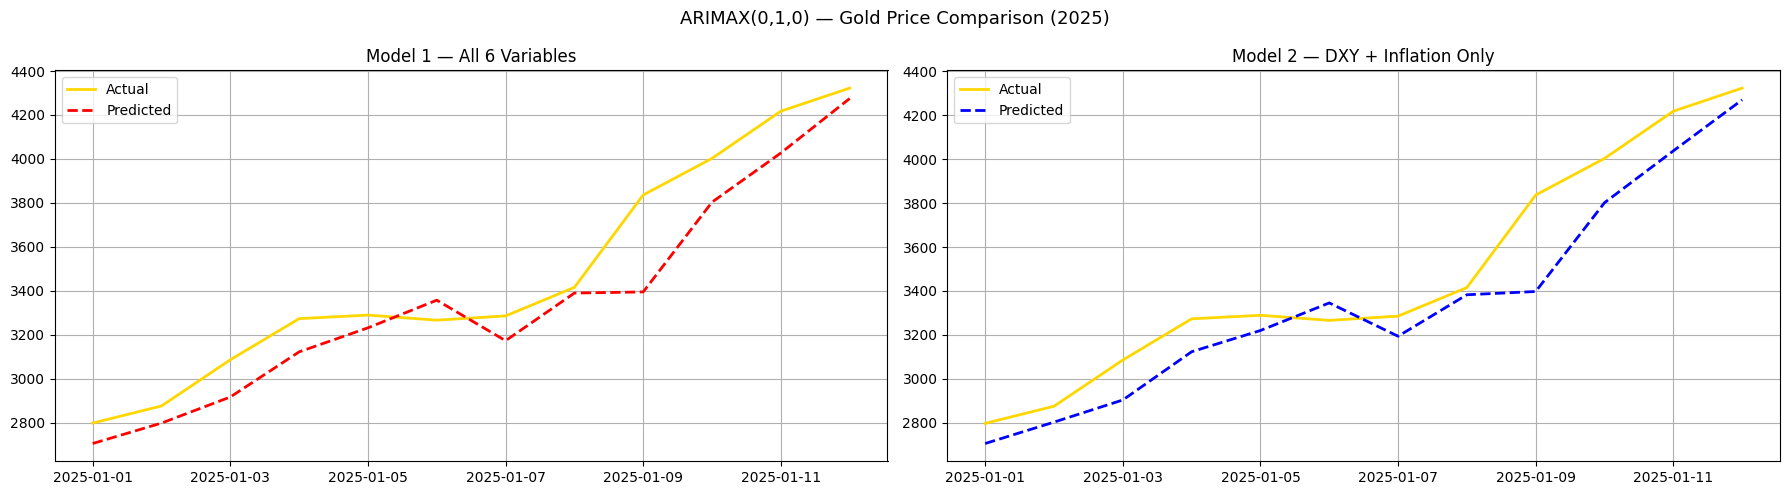

Metric      All Variables    DXY+Inflation
------------------------------------------
MAE                138.12           136.79
RMSE               174.20           172.66
MAPE                3.91%            3.87%

── Model 1 — All Variables ──
                      Actual  Predicted  Difference  Error (%)
2025-01-01 00:00:00  2798.20    2705.31       92.89       3.32
2025-01-02 00:00:00  2876.21    2798.25       77.96       2.71
2025-01-03 00:00:00  3086.34    2916.90      169.44       5.49
2025-01-04 00:00:00  3273.50    3122.31      151.19       4.62
2025-01-05 00:00:00  3289.55    3231.65       57.90       1.76
2025-01-06 00:00:00  3266.41    3357.46      -91.05       2.79
2025-01-07 00:00:00  3285.78    3173.00      112.78       3.43
2025-01-08 00:00:00  3415.77    3389.78       25.99       0.76
2025-01-09 00:00:00  3836.23    3395.01      441.22      11.50
2025-01-10 00:00:00  4002.77    3803.48      199.29       4.98
2025-01-11 00:00:00  4217.36    4027.14      190.22       4.5

In [372]:
# ── Side by side charts ─────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(18, 5))

axes[0].plot(actual_price.index, actual_price, label="Actual", color="gold", linewidth=2)
axes[0].plot(pred_price_rolling.index, pred_price_rolling, label="Predicted",
             color="red", linestyle="--", linewidth=2)
axes[0].set_title("Model 1 — All 6 Variables")
axes[0].legend()
axes[0].grid(True)

axes[1].plot(actual_price.index, actual_price, label="Actual", color="gold", linewidth=2)
axes[1].plot(pred_price_v2.index, pred_price_v2, label="Predicted",
             color="blue", linestyle="--", linewidth=2)
axes[1].set_title("Model 2 — DXY + Inflation Only")
axes[1].legend()
axes[1].grid(True)

plt.suptitle("ARIMAX(0,1,0) — Gold Price Comparison (2025)", fontsize=13)
plt.tight_layout()
plt.show()

# ── Metrics ─────────────────────────────────────────────────────
mae_all  = 138.12
rmse_all = 174.20
mape_all = 3.91

mae_sig  = mean_absolute_error(actual_price, pred_price_v2)
rmse_sig = np.sqrt(mean_squared_error(actual_price, pred_price_v2))
mape_sig = np.mean(np.abs((actual_price - pred_price_v2) / actual_price)) * 100

print(f"{'Metric':<8} {'All Variables':>16} {'DXY+Inflation':>16}")
print("-" * 42)
print(f"{'MAE':<8} {mae_all:>16.2f} {mae_sig:>16.2f}")
print(f"{'RMSE':<8} {rmse_all:>16.2f} {rmse_sig:>16.2f}")
print(f"{'MAPE':<8} {mape_all:>15.2f}% {mape_sig:>15.2f}%")

# ── Comparison tables ───────────────────────────────────────────
def make_table_gold(actual, predicted, mape, label):
    tbl = pd.DataFrame({
        "Actual"     : actual.values,
        "Predicted"  : predicted.values,
        "Difference" : (actual.values - predicted.values),
        "Error (%)"  : (abs(actual.values - predicted.values) / actual.values * 100)
    }, index=actual.index).round(2)

    avg = pd.DataFrame({
        "Actual"     : [round(actual.mean(), 2)],
        "Predicted"  : [round(predicted.mean(), 2)],
        "Difference" : [round((actual.values - predicted.values).mean(), 2)],
        "Error (%)"  : [round(mape, 2)]
    }, index=["AVERAGE"])

    print(f"\n── {label} ──")
    print(pd.concat([tbl, avg]).to_string())

make_table_gold(actual_price, pred_price_rolling, mape_all, "Model 1 — All Variables")
make_table_gold(actual_price, pred_price_v2, mape_sig, "Model 2 — DXY + Inflation")